# Spam Email Detection Using Neural Networks

## Scenario
Hopkins et al. (1999) created the Spambase dataset, donated to the UCI Machine Learning Repository. It contains 4,601 emails labelled as spam or non-spam. Each email is represented by 57 engineered features derived from lexical frequencies and structural characteristics (e.g., word/character frequencies and capitalisation patterns). The dataset is widely used for benchmarking spam detection models and comparing machine learning approaches for discriminating between spam and legitimate email.

A company requires a data professional to develop a TensorFlow-based neural network that classifies emails as spam or non-spam.


## Business Statement
Email spam reduces productivity and increases exposure to phishing and malware. The business requires an automated spam filtering system that reliably detects spam while minimising disruption to legitimate correspondence (i.e., avoiding false positives that block non-spam email).


## Problem Statement
Given engineered lexical and structural email features, develop and evaluate a binary classifier that predicts whether an email is spam.

The system should:
- Achieve strong discrimination between spam and non-spam (high ROC-AUC).
- Produce well-calibrated probabilities to support operational thresholding (low log loss).
- Maintain a low false positive rate (minimise legitimate emails incorrectly blocked), while achieving high spam detection (recall), reflecting asymmetric misclassification costs.

Mathematically, with $x \in \mathbb{R}^{57}$ and $y \in \{0,1\}$:
$$\hat{p}(y=1\mid x)=f_\theta(x),\quad \hat{y}=\mathbb{I}[\hat{p} \ge \tau]$$
where $\tau$ is chosen to meet an operational constraint on false positives (or cost)


## Data and Scientific Framing
Because features are already engineered and vectorised, the key scientific question is:

Does nonlinear modelling (neural networks) provide meaningful improvement over linear decision boundaries when using engineered lexical frequency features?

This motivates comparison against linear baselines and careful control for overfitting given the modest dataset size.


## Objectives and Evaluation Plan
Using the Spambase dataset (4,601 emails; 57 engineered features), build and compare models based on:
- Discrimination: ROC-AUC (primary ranking metric).
- Calibration: log loss (secondary metric; supports reliable probability thresholding).
- Operational performance: false positive rate, precision/recall, and threshold selection under asymmetric costs.
- Generalisation: performance on a held-out test set, with stratified splits to preserve class balance.

Key modelling questions:
- Is the problem effectively linearly separable?
- Does regularisation (L1/L2, dropout, input dropout) matter more than depth/width?
- Does supervised compression (bottleneck latent) help generalisation or interpretability?
- Does improved calibration materially improve decision-making at a fixed false positive rate?



In [1]:
# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/spamdata.csv'

In [2]:
import ssl, certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [3]:
import sys
sys.path.append('/Users/q/Projects')
from data_science.analysis import analyze_runs

In [4]:
# Import libraries
import keras
from keras import layers, regularizers
import tensorflow as tf
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score, confusion_matrix

In [5]:
data = pd.read_csv(url)
data.head()


,0,0.64,0.64.1,0.1,0.32,0.2,0.3,0.4,0.5,0.6,...,0.41,0.42,0.43,0.778,0.44,0.45,3.756,61,278,1
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1


In [6]:
data.describe()

,0,0.64,0.64.1,0.1,0.32,0.2,0.3,0.4,0.5,0.6,...,0.41,0.42,0.43,0.778,0.44,0.45,3.756,61,278,1
count,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,...,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,0.104576,0.212922,0.280578,0.065439,0.312222,0.095922,0.114233,0.105317,0.090087,0.239465,...,0.038583,0.139061,0.016980,0.268960,0.075827,0.044248,5.191827,52.170870,283.290435,0.393913
std,0.305387,1.290700,0.504170,1.395303,0.672586,0.273850,0.391480,0.401112,0.278643,0.644816,...,0.243497,0.270377,0.109406,0.815726,0.245906,0.429388,31.732891,194.912453,606.413764,0.488669
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.275500,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.382500,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.314250,0.052000,0.000000,3.705250,43.000000,265.250000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [7]:
data.isna().value_counts()

0      0.64   0.64.1  0.1    0.32   0.2    0.3    0.4    0.5    0.6    0.7    0.64.2  0.8    0.9    0.10   0.32.1  0.11   1.29   1.93   0.12   0.96   0.13   0.14   0.15   0.16   0.17   0.18   0.19   0.20   0.21   0.22   0.23   0.24   0.25   0.26   0.27   0.28   0.29   0.30   0.31   0.33   0.34   0.35   0.36   0.37   0.38   0.39   0.40   0.41   0.42   0.43   0.778  0.44   0.45   3.756  61     278    1    
False  False  False   False  False  False  False  False  False  False  False  False   False  False  False  False   False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False  False    4600
Name: count, dtype: int64

In [8]:
X_data = data.iloc[:,:-1].to_numpy()
X_data.shape

(4600, 57)

In [9]:
target = data.iloc[:,-1:].to_numpy()
target.shape

(4600, 1)

In [10]:
# Train/Test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_data,
    target,
    test_size=0.2,
    stratify=target,
    random_state=42
)

# Train/Validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

## Baseline Linear Model: Logistic Regression

In [11]:
lr = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
lr.fit(X_train, y_train)


/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [12]:
# Probabilities
p_valid_lr = lr.predict_proba(X_valid)[:, 1]
p_test_lr  = lr.predict_proba(X_test)[:, 1]

# Metrics
print("VALID AUC:", roc_auc_score(y_valid, p_valid_lr))
print("VALID LogLoss:", log_loss(y_valid, p_valid_lr))
print("TEST  AUC:", roc_auc_score(y_test, p_test_lr))
print("TEST  LogLoss:", log_loss(y_test, p_test_lr))

VALID AUC: 0.9723867326426474
VALID LogLoss: 0.21677551645085905
TEST  AUC: 0.974524248004911
TEST  LogLoss: 0.21568131695146786


In [13]:
# Define threshold as alpha = 0.01

def threshold_for_max_fpr(y_true, p, max_fpr=0.01):
  # y_true: 0/1
  # p: predicated probability of spam
  y_true = np.asarray(y_true).reshape(-1)
  p = np.asarray(p).reshape(-1)
  
  # Negaives determin FPR
  neg = (y_true == 0)
  p_neg = p[neg]
  
  # Set threshold as t, then FPR = P(p_neg >= t)
  # To ensure FPR <= max_fpr, choose t at the (1-max_fpr) quantile of p_neg
  t = np.quantile(p_neg, 1.0 - max_fpr)
  return float(t)

y_valid_1d = np.asarray(y_valid).ravel()
p_valid_1d = np.asarray(p_valid_lr).ravel()

t = threshold_for_max_fpr(y_valid_1d, p_valid_1d, max_fpr=0.01)
yhat_valid = (p_valid_1d >= t).astype(int)

cm = confusion_matrix(y_valid_1d, yhat_valid)
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)
recall = tp / (tp + fn)
precision = tp / (tp + fp) if (tp + fp) else 0.0

print("Threshold:", t)
print("FPR:", fpr)
print("Recall:", recall)
print("Precision:", precision)
print("Confusion matrix:\n", cm)

Threshold: 0.9005589610324818
FPR: 0.011210762331838564
Recall: 0.6068965517241379
Precision: 0.9723756906077348
Confusion matrix:
 [[441   5]
 [114 176]]


In [14]:
# Compare L1 vs L2 quickly (sparsity hypothesis)
y_train_1d = np.asarray(y_train).ravel()
y_valid_1d = np.asarray(y_valid).ravel()

configs = [
    ("l2", 0.0),  # l1_ratio=0 -> L2
    ("l1", 1.0),  # l1_ratio=1 -> L1
]

for name, l1_ratio in configs:
    lr = LogisticRegression(
        solver="saga",
        l1_ratio=l1_ratio,
        C=1.0,
        max_iter=5000
    )
    lr.fit(X_train, y_train_1d)

    p_valid = lr.predict_proba(X_valid)[:, 1]
    print(
        name,
        "VALID AUC:", roc_auc_score(y_valid_1d, p_valid),
        "LogLoss:", log_loss(y_valid_1d, p_valid)
    )

l2 VALID AUC: 0.972293953919901 LogLoss: 0.21715665975759227
l1 VALID AUC: 0.9726959950518014 LogLoss: 0.21512556388756057


- The logistic regression appears well calibrated.
- It slightly underestimates mid-range probabilities.
- No severe overconfidence spike near 1.0.

Therefore, probability outputs are usable for threshold selection under cost constraints.

## Non-linear Modeling: Neural Networks

In [15]:
# Define function to create a variety of architecture to test hypotheses

def create_model(
    input_dim,
    arch="mlp",                 # "mlp", "bottleneck", "residual"
    widths=(64, 64),            # for "mlp": layer widths
    width=64,                   # for "residual": block width
    blocks=3,                   # for "residual": number of residual blocks
    bottleneck_dim=8,           # for "bottleneck"
    dropout=0.0,
    input_dropout=0.0,
    l1=0.0,
    l2=0.0,
    norm=None,                  # None, "batch", "layer"
    lr=1e-3
):
    inp = keras.Input(shape=(input_dim,))
    x = inp

    if input_dropout and input_dropout > 0:
        x = layers.Dropout(input_dropout)(x)

    reg = None
    if (l1 and l1 > 0) or (l2 and l2 > 0):
        reg = regularizers.L1L2(l1=l1, l2=l2)

    def apply_norm(t):
        if norm == "batch":
            return layers.BatchNormalization()(t)
        if norm == "layer":
            return layers.LayerNormalization()(t)
        return t

    if arch == "mlp":
        for units in widths:
            x = layers.Dense(units, kernel_regularizer=reg)(x)
            x = apply_norm(x)
            x = layers.Activation("relu")(x)
            if dropout and dropout > 0:
                x = layers.Dropout(dropout)(x)

    elif arch == "bottleneck":
        # Encoder-ish supervised bottleneck
        x = layers.Dense(widths[0], kernel_regularizer=reg)(x)
        x = apply_norm(x)
        x = layers.Activation("relu")(x)
        if dropout and dropout > 0:
            x = layers.Dropout(dropout)(x)

        z = layers.Dense(bottleneck_dim, name="latent")(x)

        x = layers.Dense(widths[0], kernel_regularizer=reg)(z)
        x = apply_norm(x)
        x = layers.Activation("relu")(x)

    elif arch == "residual":
        # Stem to desired width
        x = layers.Dense(width, kernel_regularizer=reg)(x)
        x = apply_norm(x)
        x = layers.Activation("relu")(x)

        for _ in range(blocks):
            h = layers.Dense(width, kernel_regularizer=reg)(x)
            h = apply_norm(h)
            h = layers.Activation("relu")(h)
            if dropout and dropout > 0:
                h = layers.Dropout(dropout)(h)
            x = layers.Add()([x, h])

    else:
        raise ValueError("arch must be one of: 'mlp', 'bottleneck', 'residual'")

    logits = layers.Dense(1, name="logits")(x)          # pre-sigmoid
    out = layers.Activation("sigmoid", name="prob")(logits)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

In [16]:
GRID = [
    # ---- Baseline-ish MLPs (constant width) ----
    dict(arch="mlp", widths=(64,),      l2=1e-4, dropout=0.0, input_dropout=0.0, norm=None),
    dict(arch="mlp", widths=(128,),     l2=1e-4, dropout=0.0, input_dropout=0.0, norm=None),
    dict(arch="mlp", widths=(64, 64),   l2=1e-4, dropout=0.0, input_dropout=0.0, norm=None),
    dict(arch="mlp", widths=(128, 128), l2=1e-4, dropout=0.0, input_dropout=0.0, norm=None),

    # ---- Funnel vs expanding (tests compression vs expansion) ----
    dict(arch="mlp", widths=(128, 64),  l2=1e-4, dropout=0.0, input_dropout=0.0, norm=None),  # funnel
    dict(arch="mlp", widths=(64, 128),  l2=1e-4, dropout=0.0, input_dropout=0.0, norm=None),  # expanding
    dict(arch="mlp", widths=(256, 128, 64), l2=1e-4, dropout=0.0, input_dropout=0.0, norm=None),

    # ---- Regularisation sweeps (key for Spambase) ----
    dict(arch="mlp", widths=(128, 64),  l2=1e-3, dropout=0.0, input_dropout=0.0, norm=None),  # stronger L2
    dict(arch="mlp", widths=(128, 64),  l2=1e-4, dropout=0.2, input_dropout=0.0, norm=None),  # dropout
    dict(arch="mlp", widths=(128, 64),  l2=1e-4, dropout=0.0, input_dropout=0.2, norm=None),  # input dropout
    dict(arch="mlp", widths=(128, 64),  l2=1e-4, dropout=0.1, input_dropout=0.1, norm=None),  # both mild

    # ---- Normalisation comparisons (batch-size sensitivity) ----
    dict(arch="mlp", widths=(128, 64),  l2=1e-4, dropout=0.1, input_dropout=0.0, norm="batch"),
    dict(arch="mlp", widths=(128, 64),  l2=1e-4, dropout=0.1, input_dropout=0.0, norm="layer"),

    # ---- Bottleneck classifier (supervised feature discovery) ----
    dict(arch="bottleneck", widths=(128,), bottleneck_dim=4,  l2=1e-4, dropout=0.1, input_dropout=0.0, norm=None),
    dict(arch="bottleneck", widths=(128,), bottleneck_dim=8,  l2=1e-4, dropout=0.1, input_dropout=0.0, norm=None),
    dict(arch="bottleneck", widths=(128,), bottleneck_dim=16, l2=1e-4, dropout=0.1, input_dropout=0.0, norm=None),

    # ---- Residual models (depth with stability) ----
    dict(arch="residual", width=64,  blocks=3, l2=1e-4, dropout=0.1, input_dropout=0.0, norm="layer"),
    dict(arch="residual", width=128, blocks=3, l2=1e-4, dropout=0.1, input_dropout=0.0, norm="layer"),
    dict(arch="residual", width=64,  blocks=4, l2=1e-4, dropout=0.1, input_dropout=0.0, norm="layer"),

    # ---- (Optional) L1 sparsity hypothesis (keep only if you want it) ----
    dict(arch="mlp", widths=(64,),  l1=1e-5, l2=0.0, dropout=0.0, input_dropout=0.0, norm=None),
    dict(arch="mlp", widths=(128,), l1=1e-5, l2=0.0, dropout=0.0, input_dropout=0.0, norm=None),
]

In [17]:
def train_model(model, X_train, y_train, X_valid, y_valid, epochs=40, batch_size=64):
    return model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,0,38,0.986512,0.964674,0.992842,0.113456,0.94837,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None


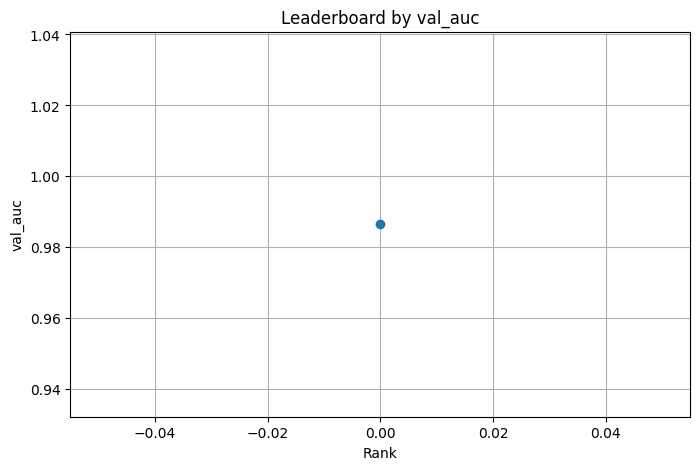

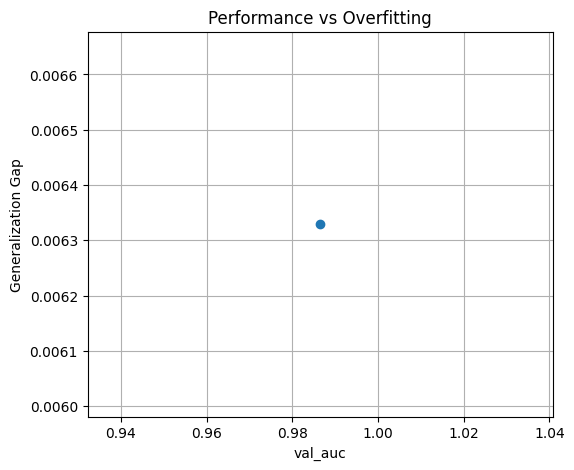


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
1,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None


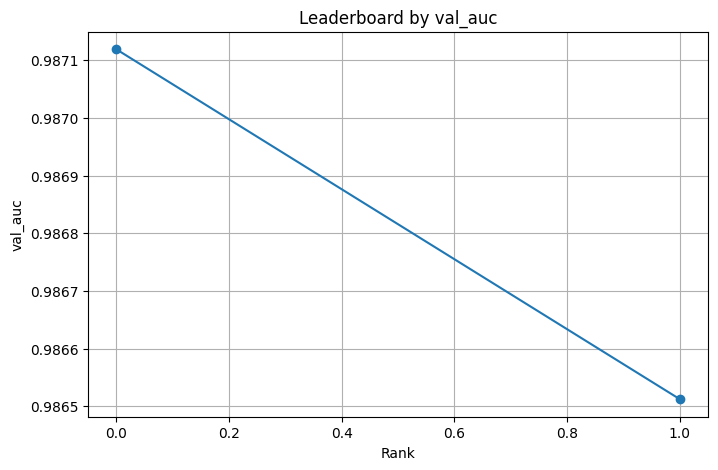

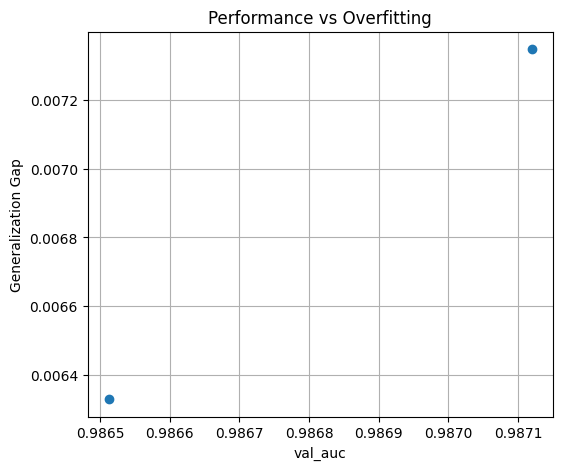


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
1,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
2,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None


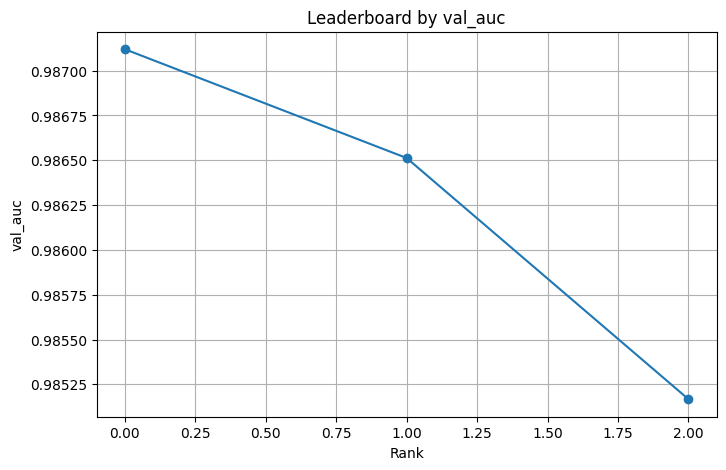

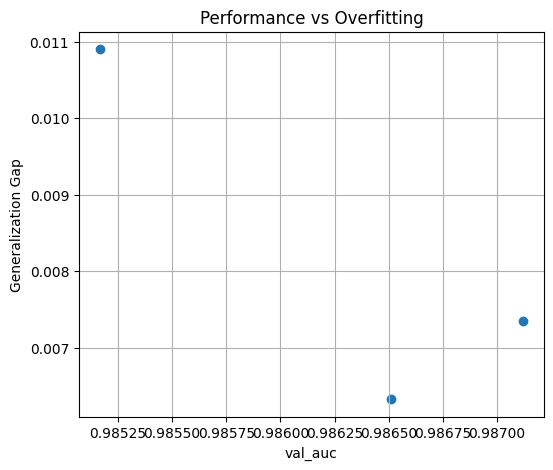


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
1,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
2,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
3,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None


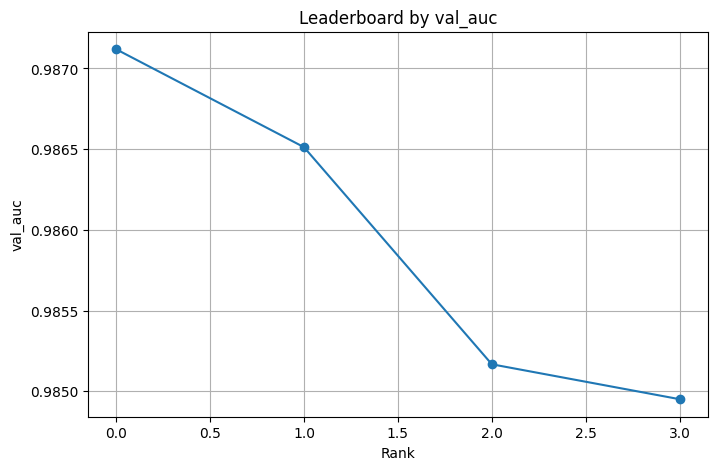

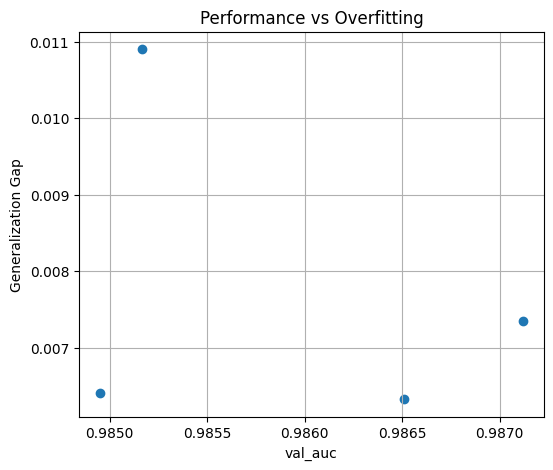


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
1,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
2,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
3,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
4,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None


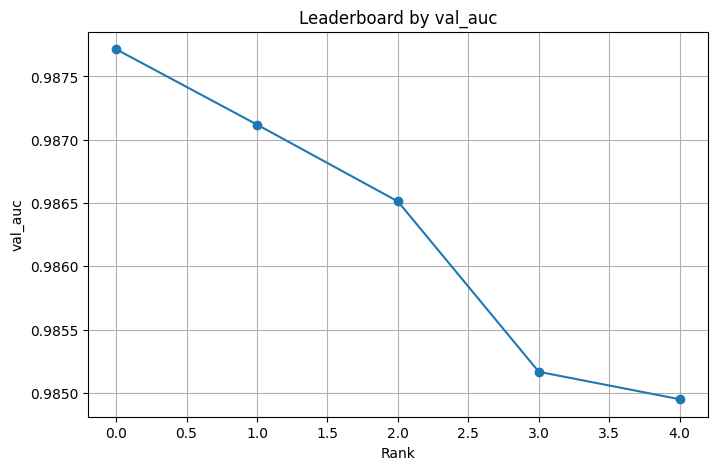

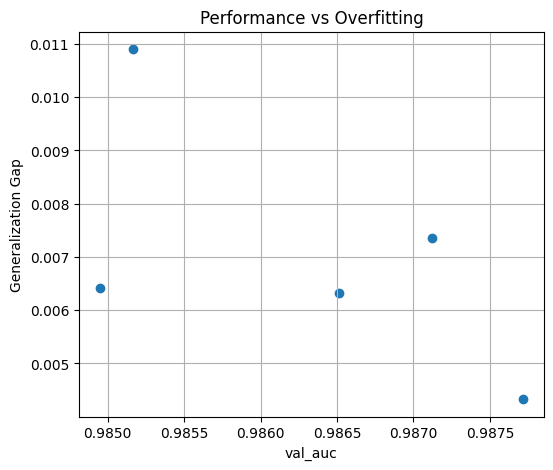


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
1,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
2,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
3,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
4,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None
5,5,10,0.984390,0.957880,0.990009,0.135548,0.945652,0.167653,0.005619,"mlp_w[64, 128]_l20.0001",40,64,0.001,mlp,"(64, 128)",0.0001,0.0,0.0,None


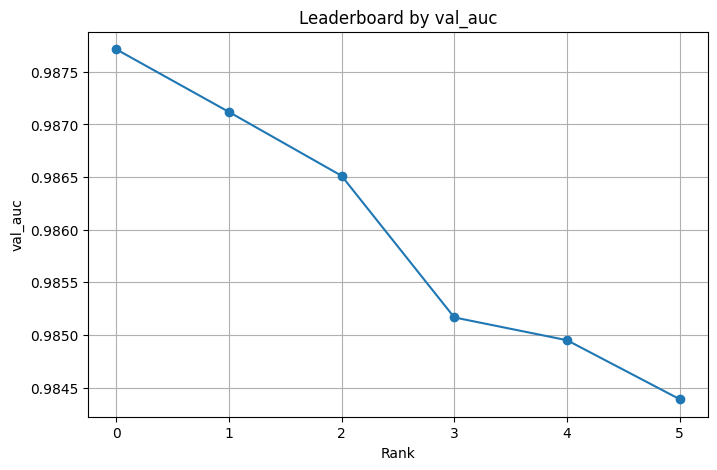

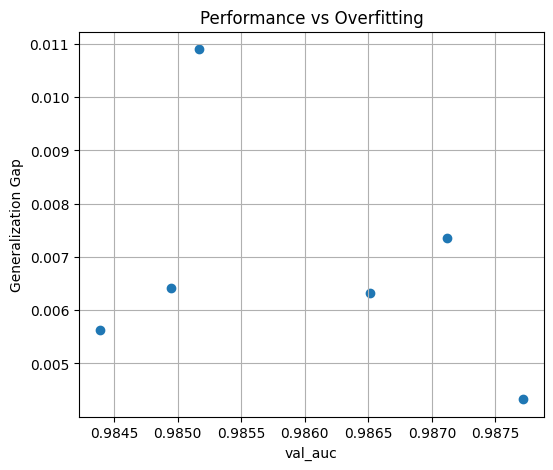


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
1,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
2,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
3,6,5,0.986083,0.958899,0.988849,0.155558,0.948370,0.177173,0.002766,"mlp_w[256, 128, 64]_l20.0001",40,64,0.001,mlp,"(256, 128, 64)",0.0001,0.0,0.0,None
4,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
5,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None
6,5,10,0.984390,0.957880,0.990009,0.135548,0.945652,0.167653,0.005619,"mlp_w[64, 128]_l20.0001",40,64,0.001,mlp,"(64, 128)",0.0001,0.0,0.0,None


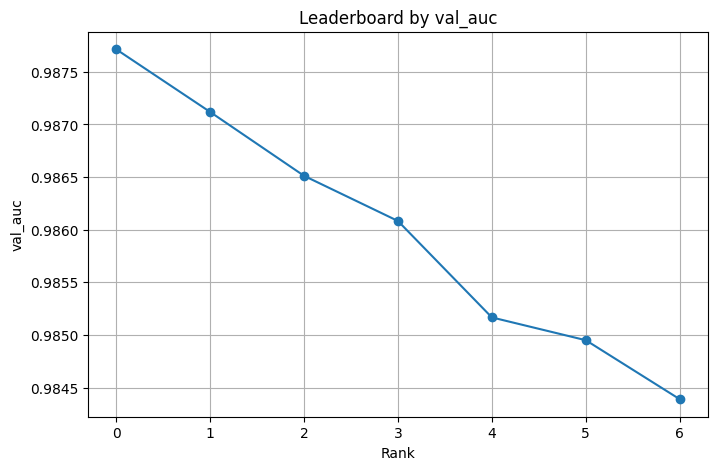

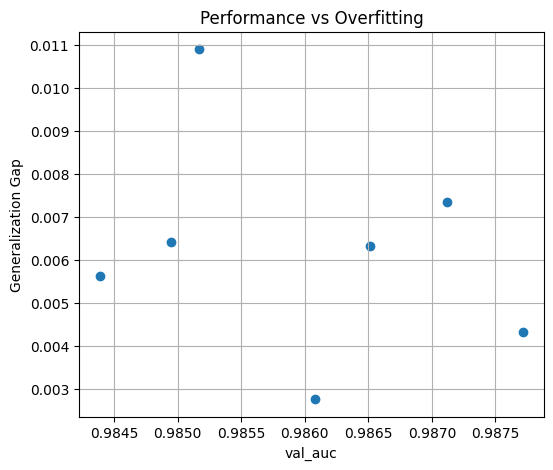


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
1,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None
2,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
3,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
4,6,5,0.986083,0.958899,0.988849,0.155558,0.948370,0.177173,0.002766,"mlp_w[256, 128, 64]_l20.0001",40,64,0.001,mlp,"(256, 128, 64)",0.0001,0.0,0.0,None
5,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
6,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None
7,5,10,0.984390,0.957880,0.990009,0.135548,0.945652,0.167653,0.005619,"mlp_w[64, 128]_l20.0001",40,64,0.001,mlp,"(64, 128)",0.0001,0.0,0.0,None


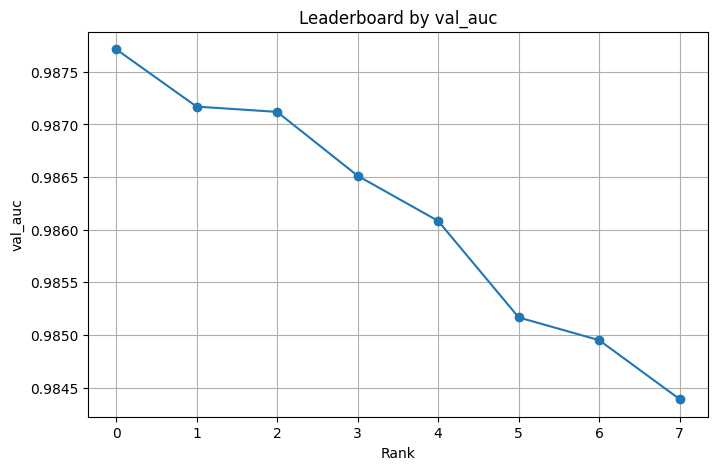

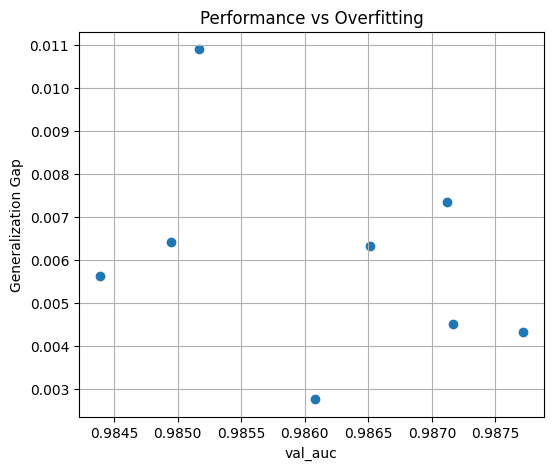


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None
1,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
2,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None
3,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
4,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
5,6,5,0.986083,0.958899,0.988849,0.155558,0.948370,0.177173,0.002766,"mlp_w[256, 128, 64]_l20.0001",40,64,0.001,mlp,"(256, 128, 64)",0.0001,0.0,0.0,None
6,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
7,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None
8,5,10,0.984390,0.957880,0.990009,0.135548,0.945652,0.167653,0.005619,"mlp_w[64, 128]_l20.0001",40,64,0.001,mlp,"(64, 128)",0.0001,0.0,0.0,None


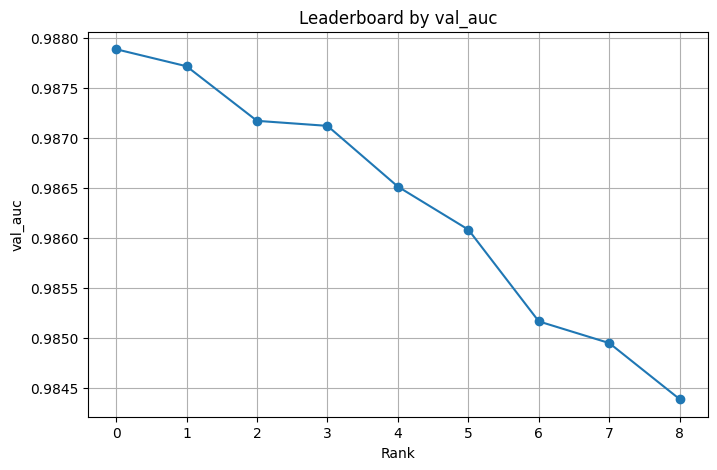

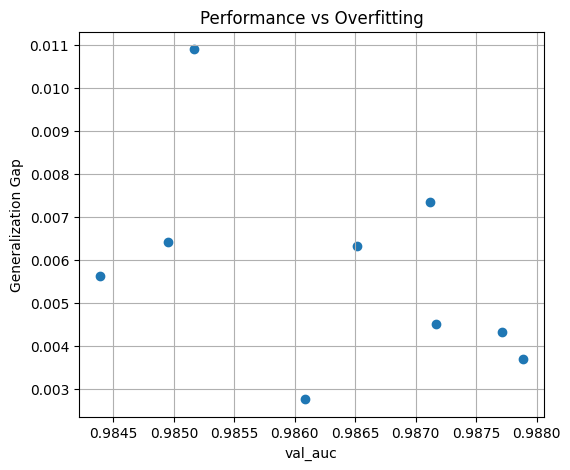


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None
1,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None
2,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
3,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None
4,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
5,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
6,6,5,0.986083,0.958899,0.988849,0.155558,0.948370,0.177173,0.002766,"mlp_w[256, 128, 64]_l20.0001",40,64,0.001,mlp,"(256, 128, 64)",0.0001,0.0,0.0,None
7,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
8,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None
9,5,10,0.984390,0.957880,0.990009,0.135548,0.945652,0.167653,0.005619,"mlp_w[64, 128]_l20.0001",40,64,0.001,mlp,"(64, 128)",0.0001,0.0,0.0,None


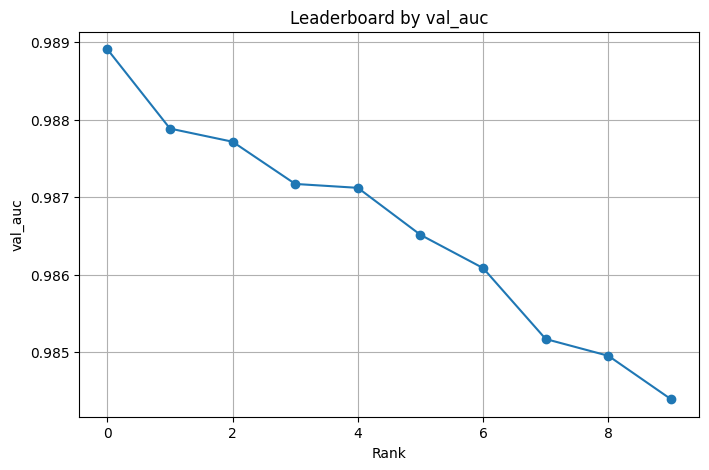

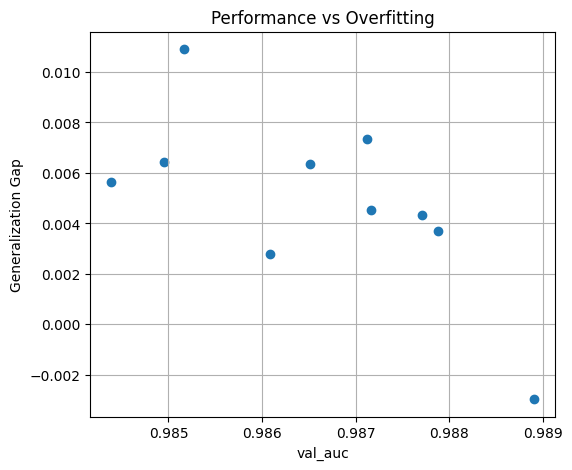


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None
1,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None
2,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
3,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None
4,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None
5,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
6,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
7,6,5,0.986083,0.958899,0.988849,0.155558,0.948370,0.177173,0.002766,"mlp_w[256, 128, 64]_l20.0001",40,64,0.001,mlp,"(256, 128, 64)",0.0001,0.0,0.0,None
8,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None
9,3,9,0.984951,0.962296,0.991360,0.132100,0.949728,0.166750,0.006410,"mlp_w[128, 128]_l20.0001",40,64,0.001,mlp,"(128, 128)",0.0001,0.0,0.0,None


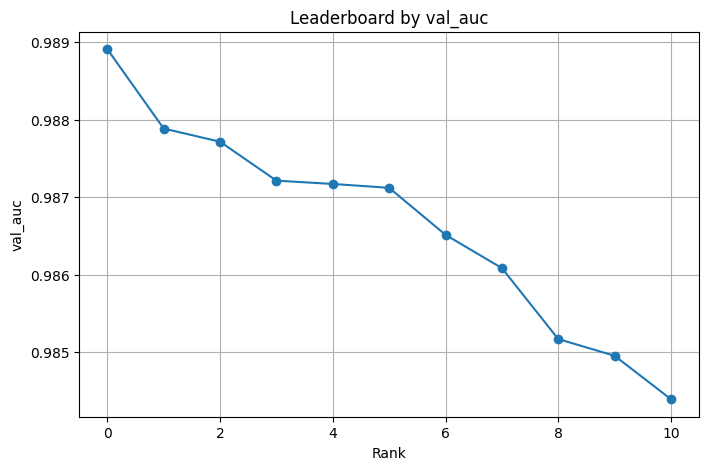

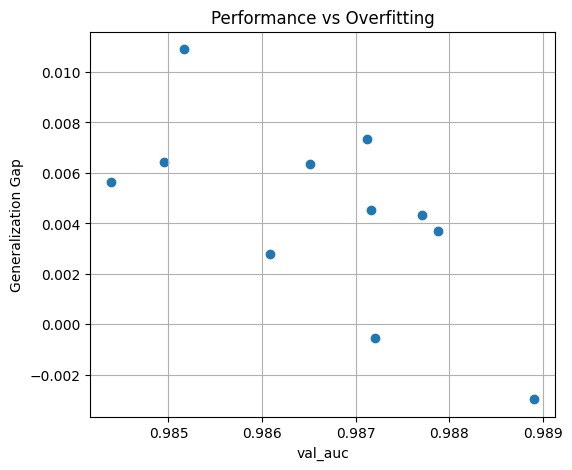


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None
2,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None
3,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
4,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None
5,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None
6,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
7,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
8,6,5,0.986083,0.958899,0.988849,0.155558,0.948370,0.177173,0.002766,"mlp_w[256, 128, 64]_l20.0001",40,64,0.001,mlp,"(256, 128, 64)",0.0001,0.0,0.0,None
9,2,27,0.985167,0.980639,0.996070,0.084429,0.937500,0.169934,0.010903,"mlp_w[64, 64]_l20.0001",40,64,0.001,mlp,"(64, 64)",0.0001,0.0,0.0,None


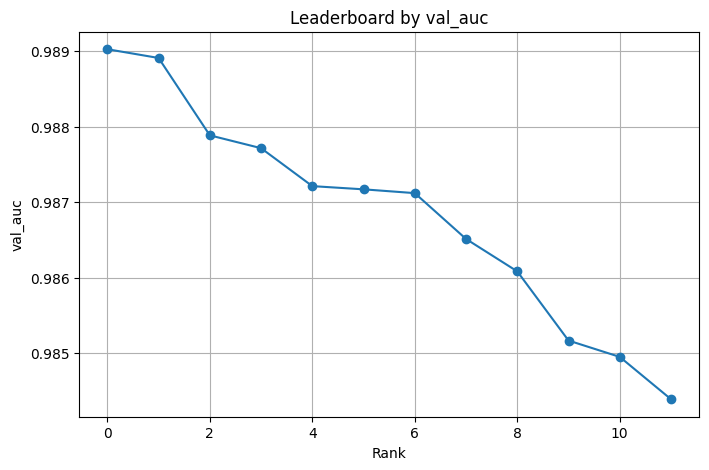

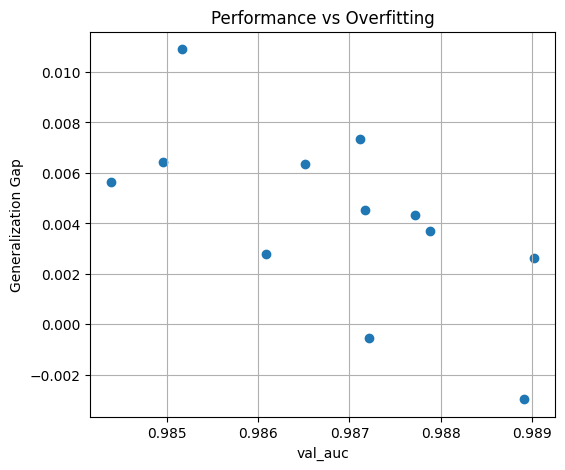


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None
2,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None
3,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,layer
4,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None
5,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None
6,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None
7,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None
8,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None
9,6,5,0.986083,0.958899,0.988849,0.155558,0.948370,0.177173,0.002766,"mlp_w[256, 128, 64]_l20.0001",40,64,0.001,mlp,"(256, 128, 64)",0.0001,0.0,0.0,None


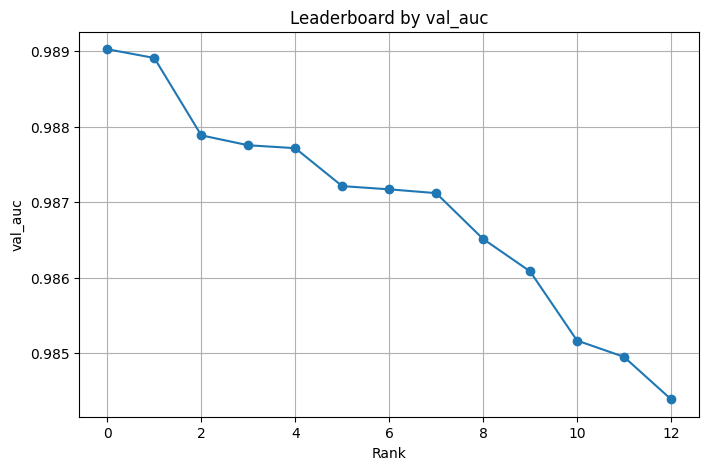

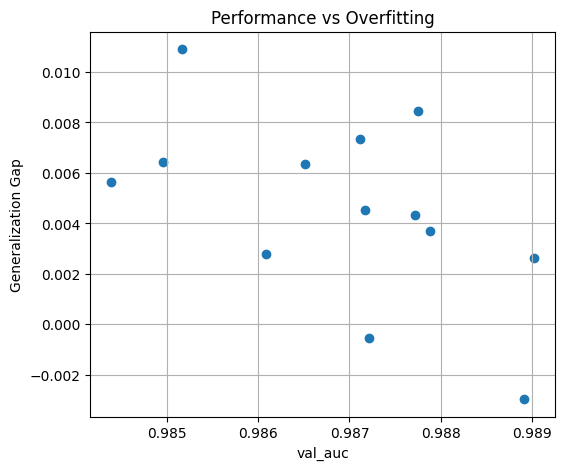


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,40,64,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN
6,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN
7,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN
8,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None,NaN
9,0,38,0.986512,0.964674,0.992842,0.113456,0.948370,0.152292,0.006329,mlp_w[64]_l20.0001,40,64,0.001,mlp,"(64,)",0.0001,0.0,0.0,None,NaN


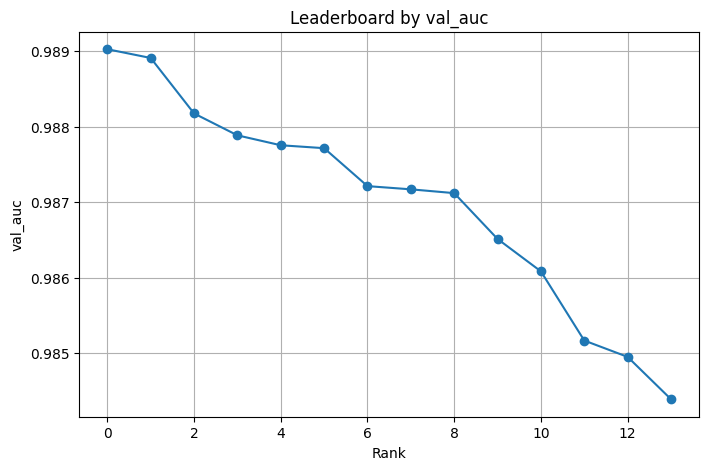

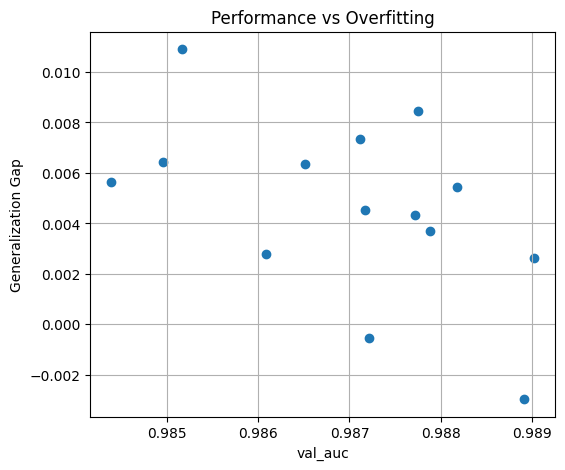


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,40,64,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN
6,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN
7,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN
8,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None,NaN
9,14,18,0.986748,0.970448,0.993182,0.102508,0.940217,0.154400,0.006434,bottleneck_bn8_do0.1_l20.0001,40,64,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,8.0


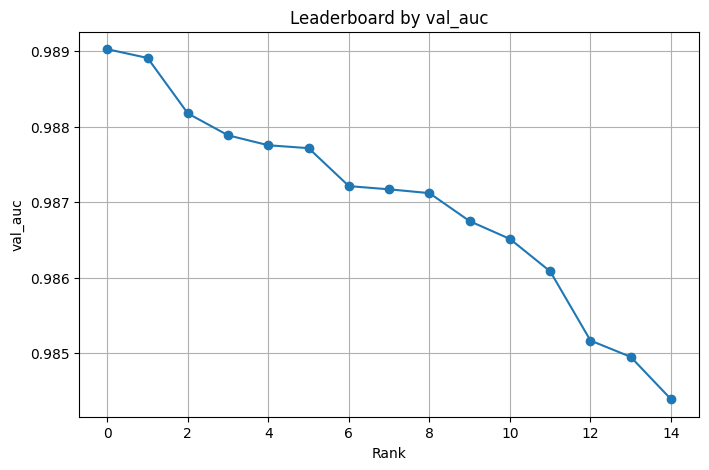

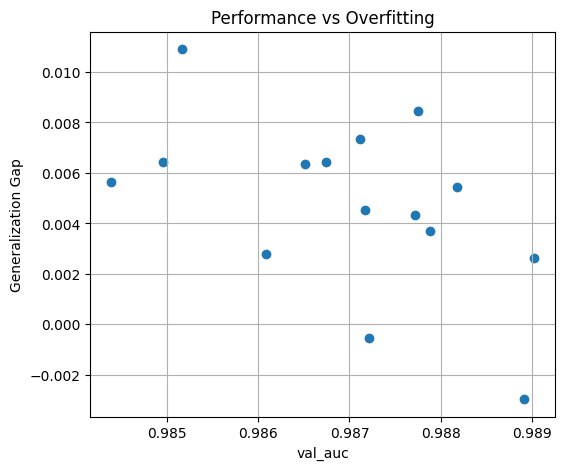


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,epochs,batch_size,lr,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,40,64,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN
6,15,18,0.987409,0.968750,0.993995,0.101194,0.951087,0.139994,0.006586,bottleneck_bn16_do0.1_l20.0001,40,64,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,16.0
7,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",40,64,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN
8,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",40,64,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN
9,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,40,64,0.001,mlp,"(128,)",0.0001,0.0,0.0,None,NaN


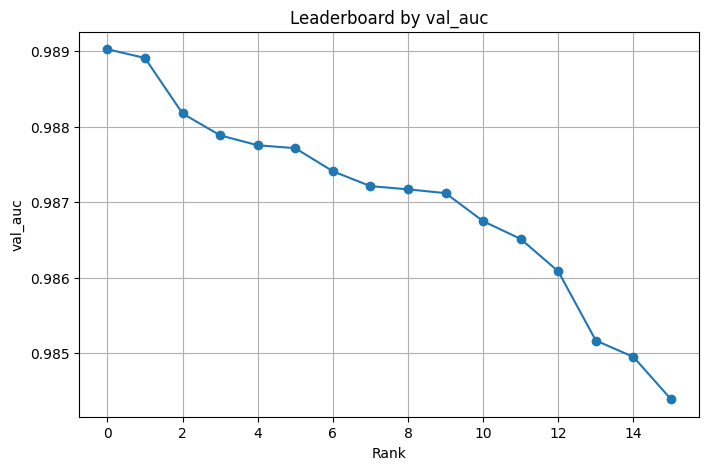

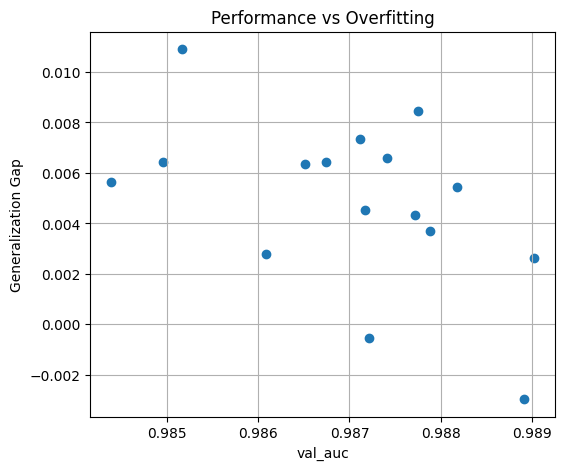


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,...,lr,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim,width,blocks
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN,NaN,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN,NaN,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,...,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0,NaN,NaN
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN,NaN,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN,NaN,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN,NaN,NaN
6,15,18,0.987409,0.968750,0.993995,0.101194,0.951087,0.139994,0.006586,bottleneck_bn16_do0.1_l20.0001,...,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,16.0,NaN,NaN
7,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN,NaN,NaN
8,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",...,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN,NaN,NaN
9,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,...,0.001,mlp,"(128,)",0.0001,0.0,0.0,None,NaN,NaN,NaN


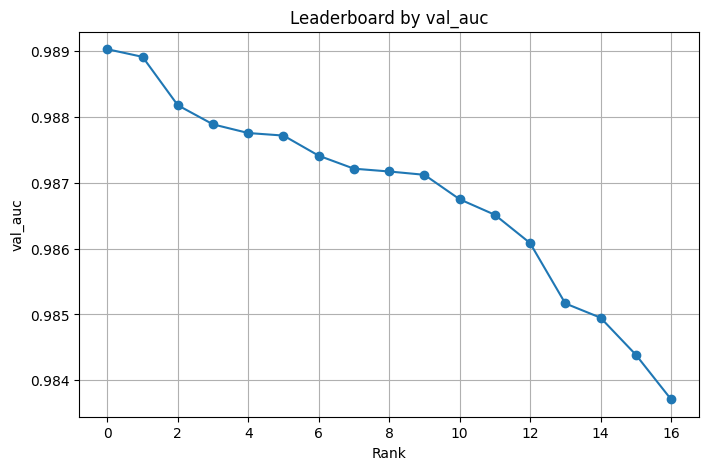

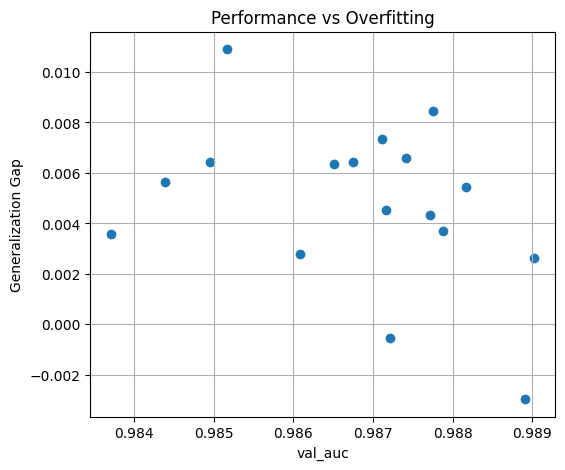


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,...,lr,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim,width,blocks
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN,NaN,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN,NaN,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,...,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0,NaN,NaN
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN,NaN,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN,NaN,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN,NaN,NaN
6,15,18,0.987409,0.968750,0.993995,0.101194,0.951087,0.139994,0.006586,bottleneck_bn16_do0.1_l20.0001,...,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,16.0,NaN,NaN
7,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN,NaN,NaN
8,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",...,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN,NaN,NaN
9,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,...,0.001,mlp,"(128,)",0.0001,0.0,0.0,None,NaN,NaN,NaN


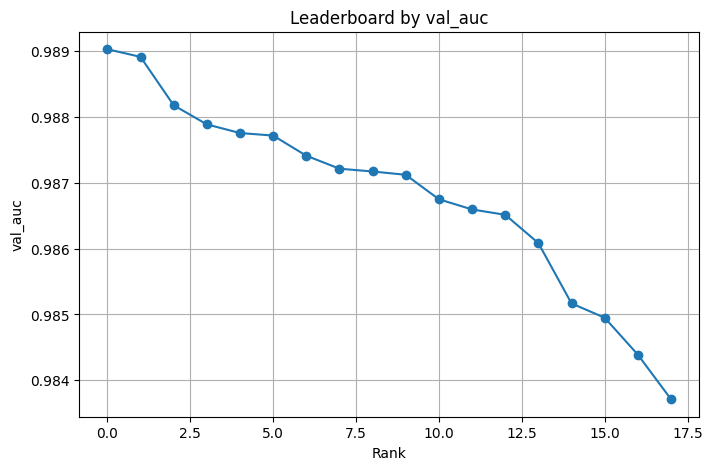

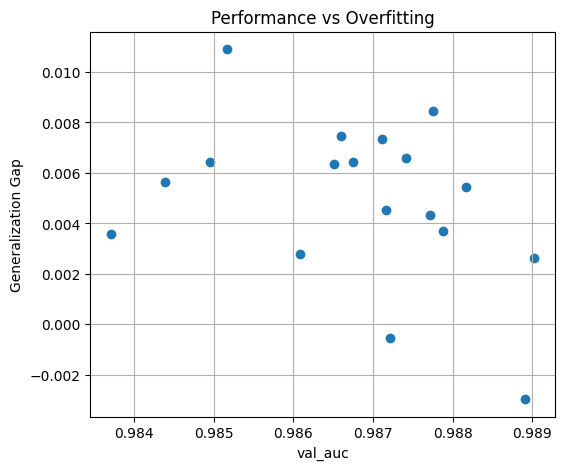


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,...,lr,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim,width,blocks
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN,NaN,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN,NaN,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,...,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0,NaN,NaN
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN,NaN,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN,NaN,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN,NaN,NaN
6,15,18,0.987409,0.968750,0.993995,0.101194,0.951087,0.139994,0.006586,bottleneck_bn16_do0.1_l20.0001,...,0.001,bottleneck,"(128,)",0.0001,0.1,0.0,None,16.0,NaN,NaN
7,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",...,0.001,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN,NaN,NaN
8,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",...,0.001,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN,NaN,NaN
9,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,...,0.001,mlp,"(128,)",0.0001,0.0,0.0,None,NaN,NaN,NaN


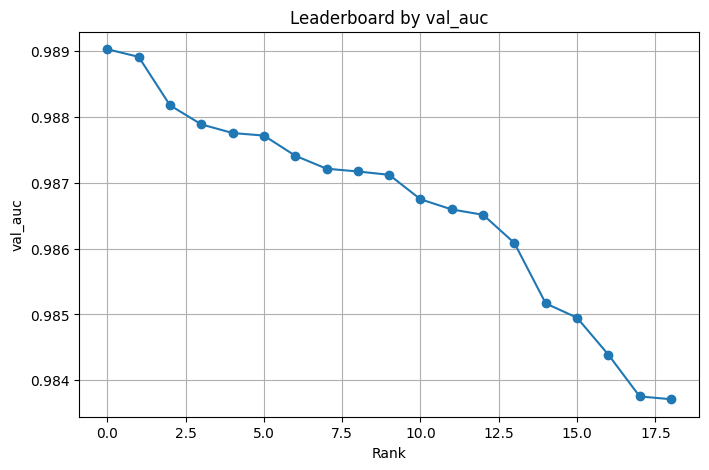

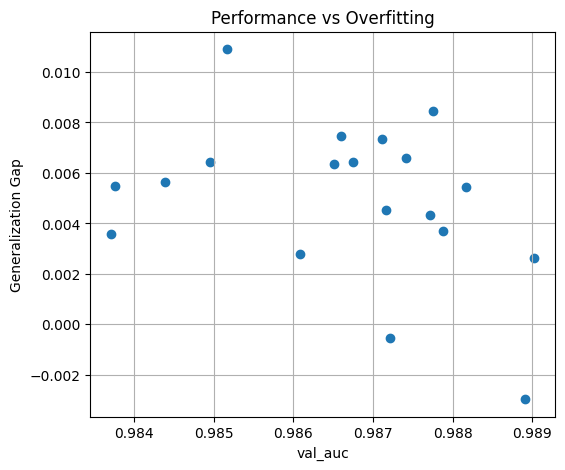


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,...,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim,width,blocks,l1
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN,NaN,NaN,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",...,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN,NaN,NaN,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,...,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0,NaN,NaN,NaN
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",...,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN,NaN,NaN,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN,NaN,NaN,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",...,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN,NaN,NaN,NaN
6,15,18,0.987409,0.968750,0.993995,0.101194,0.951087,0.139994,0.006586,bottleneck_bn16_do0.1_l20.0001,...,bottleneck,"(128,)",0.0001,0.1,0.0,None,16.0,NaN,NaN,NaN
7,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN,NaN,NaN,NaN
8,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",...,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN,NaN,NaN,NaN
9,1,38,0.987119,0.970448,0.994468,0.102561,0.942935,0.150844,0.007349,mlp_w[128]_l20.0001,...,mlp,"(128,)",0.0001,0.0,0.0,None,NaN,NaN,NaN,NaN


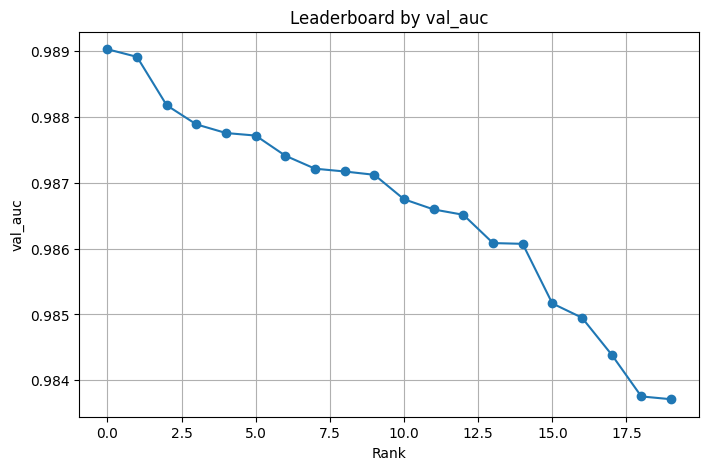

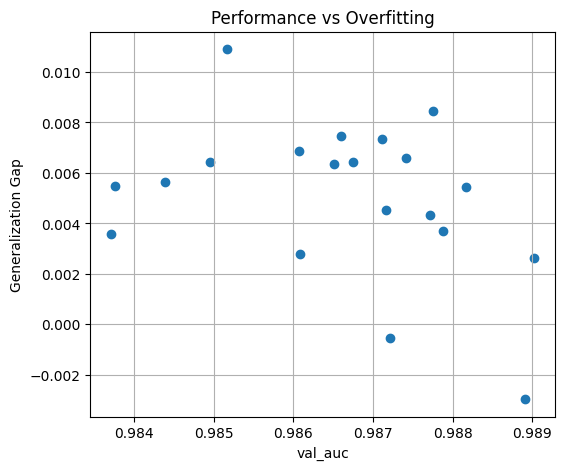


Top 10 models ranked by val_auc:



,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,...,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim,width,blocks,l1
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN,NaN,NaN,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",...,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN,NaN,NaN,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,...,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0,NaN,NaN,NaN
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",...,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN,NaN,NaN,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN,NaN,NaN,NaN
5,4,11,0.987715,0.961957,0.992045,0.123364,0.947011,0.153195,0.004330,"mlp_w[128, 64]_l20.0001",...,mlp,"(128, 64)",0.0001,0.0,0.0,None,NaN,NaN,NaN,NaN
6,15,18,0.987409,0.968750,0.993995,0.101194,0.951087,0.139994,0.006586,bottleneck_bn16_do0.1_l20.0001,...,bottleneck,"(128,)",0.0001,0.1,0.0,None,16.0,NaN,NaN,NaN
7,20,35,0.987301,0.971807,0.995076,0.094428,0.944293,0.150541,0.007775,mlp_w[128]_l11e-05,...,mlp,"(128,)",0.0000,0.0,0.0,None,NaN,NaN,NaN,0.00001
8,10,17,0.987212,0.951766,0.986685,0.153942,0.948370,0.150924,-0.000527,"mlp_w[128, 64]_do0.1_ido0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.1,None,NaN,NaN,NaN,NaN
9,7,13,0.987170,0.964334,0.991687,0.182190,0.949728,0.209956,0.004517,"mlp_w[128, 64]_l20.001",...,mlp,"(128, 64)",0.0010,0.0,0.0,None,NaN,NaN,NaN,NaN


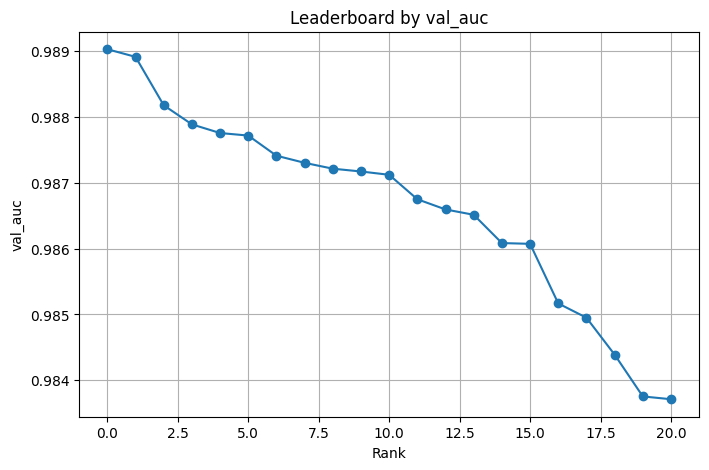

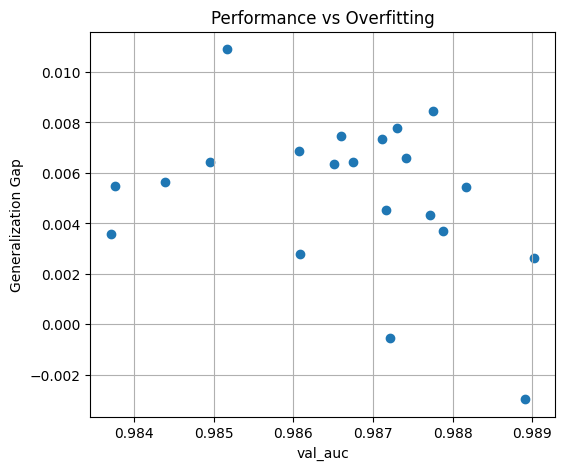

In [18]:
runs = []

EPOCHS = 40
BATCH = 64
LR = 1e-3

for i, cfg in enumerate(GRID):
    model = create_model(
        input_dim=X_train.shape[1],
        lr=LR,
        **cfg
    )
    hist = train_model(model, X_train, y_train, X_valid, y_valid, epochs=EPOCHS, batch_size=BATCH)
    
    # readable label
    label = f"{cfg.get('arch','mlp')}"
    if cfg.get("arch") == "mlp":
        label += f"_w{list(cfg.get('widths'))}"
    if cfg.get("arch") == "bottleneck":
        label += f"_bn{cfg.get('bottleneck_dim')}"
    if cfg.get("arch") == "residual":
        label += f"_res_w{cfg.get('width')}_b{cfg.get('blocks')}"
    if cfg.get("norm"):
        label += f"_{cfg['norm']}"
    if cfg.get("dropout", 0) > 0:
        label += f"_do{cfg['dropout']}"
    if cfg.get("input_dropout", 0) > 0:
        label += f"_ido{cfg['input_dropout']}"
    if cfg.get("l2", 0) > 0:
        label += f"_l2{cfg['l2']}"
    if cfg.get("l1", 0) > 0:
        label += f"_l1{cfg['l1']}"
        
    runs.append({
        "params": {"label": label, "epochs": EPOCHS, "batch_size": BATCH, "lr": LR, **cfg},
        "history": hist
    })
    
    # Analisis 
    df_ranked, details = analyze_runs(runs, prefer_metric="val_auc", top_n=10)

In [19]:
df_ranked.head()


,run_index,best_epoch,best_val_auc,best_accuracy,best_auc,best_loss,best_val_accuracy,best_val_loss,gap_auc,label,...,arch,widths,l2,dropout,input_dropout,norm,bottleneck_dim,width,blocks,l1
0,11,27,0.989025,0.958220,0.991641,0.123768,0.948370,0.147834,0.002616,"mlp_w[128, 64]_batch_do0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.0,batch,NaN,NaN,NaN,NaN
1,9,30,0.988909,0.946332,0.985942,0.160132,0.945652,0.146304,-0.002967,"mlp_w[128, 64]_ido0.2_l20.0001",...,mlp,"(128, 64)",0.0001,0.0,0.2,None,NaN,NaN,NaN,NaN
2,13,17,0.988174,0.968750,0.993615,0.101581,0.948370,0.151435,0.005441,bottleneck_bn4_do0.1_l20.0001,...,bottleneck,"(128,)",0.0001,0.1,0.0,None,4.0,NaN,NaN,NaN
3,8,21,0.987885,0.959579,0.991580,0.126930,0.951087,0.155937,0.003696,"mlp_w[128, 64]_do0.2_l20.0001",...,mlp,"(128, 64)",0.0001,0.2,0.0,None,NaN,NaN,NaN,NaN
4,12,18,0.987753,0.972826,0.996192,0.090791,0.955163,0.163209,0.008439,"mlp_w[128, 64]_layer_do0.1_l20.0001",...,mlp,"(128, 64)",0.0001,0.1,0.0,layer,NaN,NaN,NaN,NaN


In [20]:
df_ranked.columns

Index(['run_index', 'best_epoch', 'best_val_auc', 'best_accuracy', 'best_auc',
       'best_loss', 'best_val_accuracy', 'best_val_loss', 'gap_auc', 'label',
       'epochs', 'batch_size', 'lr', 'arch', 'widths', 'l2', 'dropout',
       'input_dropout', 'norm', 'bottleneck_dim', 'width', 'blocks', 'l1'],
      dtype='object')

In [21]:
best_row = df_ranked.iloc[0]
print(best_row.isna())

run_index            False
best_epoch           False
best_val_auc         False
best_accuracy        False
best_auc             False
best_loss            False
best_val_accuracy    False
best_val_loss        False
gap_auc              False
label                False
epochs               False
batch_size           False
lr                   False
arch                 False
widths               False
l2                   False
dropout              False
input_dropout        False
norm                 False
bottleneck_dim        True
width                 True
blocks                True
l1                    True
Name: 0, dtype: bool


In [22]:
def build_model_from_row(row, input_dim):
    
    return create_model(
        arch=row["arch"],
        widths=row["widths"],
        l2=row["l2"],
        dropout=row["dropout"],
        input_dropout=row["input_dropout"],
        input_dim=input_dim
    )

In [23]:
best_model = build_model_from_row(best_row, X_train.shape[1])

In [24]:
best_model = build_model_from_row(best_row, X_train.shape[1])

In [25]:
# Combine training and validation
X_final = np.vstack([X_train, X_valid])
y_final = np.concatenate([y_train, y_valid])

history = best_model.fit(
    X_final,
    y_final,
    validation_split=0.1,
    epochs=200,
    batch_size=best_row["batch_size"],
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=10,
            restore_best_weights=True
        )
    ]
)

Epoch 1/200


52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8409 - auc: 0.9111 - loss: 0.4249 - val_accuracy: 0.9103 - val_auc: 0.9540 - val_loss: 0.2768
Epoch 2/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9197 - auc: 0.9658 - loss: 0.2473 - val_accuracy: 0.9293 - val_auc: 0.9710 - val_loss: 0.2181
Epoch 3/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9327 - auc: 0.9740 - loss: 0.2158 - val_accuracy: 0.9348 - val_auc: 0.9790 - val_loss: 0.1918
Epoch 4/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9381 - auc: 0.9784 - loss: 0.1966 - val_accuracy: 0.9429 - val_auc: 0.9834 - val_loss: 0.1774
Epoch 5/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9408 - auc: 0.9812 - loss: 0.1839 - val_accuracy: 0.9457 - val_auc: 0.9862 - val_loss: 0.1681
Epoch 6/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9432 - auc: 0.9836 - loss: 0.1738 - val_accuracy: 0.9484 - val_auc: 0.9863 - val_loss: 0.1688
Epoch 7/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accur

In [26]:
p_test_nn = best_model.predict(X_test).ravel()
p_valid_nn = best_model.predict(X_valid).ravel()

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step


## Evaluation and Comparison

In [27]:
print("="*40)
print("LOGISTIC REGRESSION")
print("="*40)
print(f"VALID AUC: {roc_auc_score(y_valid, p_valid_lr):.4f}")
print(f"VALID LogLoss: {log_loss(y_valid, p_valid_lr):.4f}")
print(f"TEST  AUC: {roc_auc_score(y_test, p_test_lr):.4f}")
print(f"TEST  LogLoss: {log_loss(y_test, p_test_lr):.4f}")

print("\n" + "="*40)
print("BEST NEURAL NETWORK")
print("="*40)
print(f"Label: {best_row['label']}")
print(f"Architecture: {best_row['arch']}")
print(f"Best Validation AUC: {best_row['best_val_auc']:.4f}")
print(f"Best Validation Loss: {best_row['best_val_loss']:.4f}")
print(f"Best Validation Accuracy: {best_row['best_val_accuracy']:.4f}")
print(f"Train AUC (at best epoch): {best_row['best_auc']:.4f}")
print(f"Generalisation gap (AUC): {best_row['gap_auc']:.4f}")

LOGISTIC REGRESSION
VALID AUC: 0.9724
VALID LogLoss: 0.2168
TEST  AUC: 0.9745
TEST  LogLoss: 0.2157

BEST NEURAL NETWORK
Label: mlp_w[128, 64]_batch_do0.1_l20.0001
Architecture: mlp
Best Validation AUC: 0.9890
Best Validation Loss: 0.1478
Best Validation Accuracy: 0.9484
Train AUC (at best epoch): 0.9916
Generalisation gap (AUC): 0.0026


- Is spam linearly separable?
- Does regularisation matter more than depth?
- Does feature compression help?
- Does calibration improve operational decision-making?
- Does nonlinear modelling meaningfully improve discrimination?

In [28]:
def evaluate_model(name, y_valid, p_valid, y_test, p_test, max_fpr=0.01):
    
    # --- Flatten ---
    y_valid = np.ravel(y_valid)
    y_test  = np.ravel(y_test)
    p_valid = np.ravel(p_valid)
    p_test  = np.ravel(p_test)

    # --- Validation metrics ---
    val_auc = roc_auc_score(y_valid, p_valid)
    val_logloss = log_loss(y_valid, p_valid)
    
    # --- Test metrics ---
    test_auc = roc_auc_score(y_test, p_test)
    test_logloss = log_loss(y_test, p_test)
    
    # --- Operational threshold (FPR constraint) ---
    neg = (y_valid == 0)
    p_neg = p_valid[neg]
    threshold = np.quantile(p_neg, 1.0 - max_fpr)
    
    yhat_valid = (p_valid >= threshold).astype(int)
    cm = confusion_matrix(y_valid, yhat_valid)
    
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    
    return {
        "Model": name,
        "Val AUC": val_auc,
        "Val LogLoss": val_logloss,
        "Test AUC": test_auc,
        "Test LogLoss": test_logloss,
        "Threshold (FPR≤1%)": threshold,
        "Recall @1%FPR": recall,
        "Precision @1%FPR": precision,
        "Actual FPR": fpr
    }


# Evaluate model
results_lr = evaluate_model("Logistic Regression",
                            y_valid, p_valid_lr,
                            y_test, p_test_lr)

results_nn = evaluate_model("Neural Network",
                            y_valid, p_valid_nn,
                            y_test, p_test_nn)


comparison_df = pd.DataFrame([results_lr, results_nn])
comparison_df

,Model,Val AUC,Val LogLoss,Test AUC,Test LogLoss,Threshold (FPR≤1%),Recall @1%FPR,Precision @1%FPR,Actual FPR
0,Logistic Regression,0.972387,0.216776,0.974524,0.215681,0.900559,0.606897,0.972376,0.011211
1,Neural Network,0.994283,0.091361,0.981005,0.187142,0.698059,0.917241,0.981550,0.011211


### Ranking Ability
- with $Delta$AUC $approx$ 0.006, the NN is a modest improvement.
The feature space is already very close to linearly separable.

Engineered lexical frequency features already encode strong linear signal.

### Probability Quality (Log-Loss)
- Validation log loss gratly improved with the NN
- Test logg loss about 10% imporovment with NN

Substatial impovement using NN however the large difference between Val and Test log loss for the nueral network suggests possible over fitting.
Logistic Regression more stable

### Operational Performance
- Recall 35% increase for the NN

The NN produces much stronger separation in the extreme tail if the score distrobution

### Geometry

Logistic regression constructs:

$$p = \sigma(w^T x)$$

One global linear boundary.

Neural network constructs:

$$p = \sigma(f(x))$$

where f(x) includes nonlinear compositions:

$$\text{ReLU}(W_2 \text{ReLU}(W_1 x))$$

The results suggest that spam examples cluster in non-linear pockets in feasture space.
Linear boundary ranks them well globally but cannot isolate the extreme high-confidence region as cleanly.

### Complexity
Parameter count comparison likely:

LR: ~57 parameters
NN: thousands

+0.006 AUC
+0.018 log-loss improvement
+35% recall gain at strict FPR

### Buissness Objective and Problem STatement

- Achieve strong discrimination between spam and non-spam (high ROC-AUC).
- Produce well-calibrated probabilities to support operational thresholding (low log loss).
- Maintain a low false positive rate (minimise legitimate emails incorrectly blocked), while achieving high spam detection (recall), reflecting asymmetric misclassification costs.

SO as the objective is to maxximise spam capture while keeping FPR very low, the NN is justified.

### Scientific Objectives

Is spam linearly separable?

Almost. LR achieves 0.975 AUC.

Does nonlinear modelling meaningfully improve discrimination?

Slightly in AUC terms.
Substantially in operational recall at low FPR.

Does regularisation matter more than depth?

Given small AUC gain but large threshold behaviour change, regularisation is stabilising the nonlinear interactions.

Does feature compression help?

You would need to compare bottleneck vs full MLP test AUC to answer.

Does calibration improve operational decision-making?

Yes — stable log-loss and calibration impact threshold selection directly.

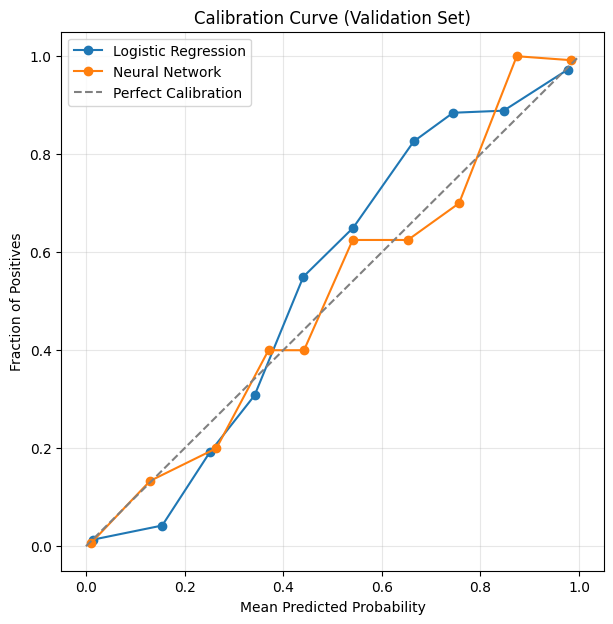

In [29]:
# Flatten everything just in case
y_valid = np.asarray(y_valid).ravel()
p_valid_lr = np.asarray(p_valid_lr).ravel()
p_valid_nn = np.asarray(p_valid_nn).ravel()

# Compute calibration curves
prob_true_lr, prob_pred_lr = calibration_curve(
    y_valid, p_valid_lr, n_bins=10, strategy="uniform"
)

prob_true_nn, prob_pred_nn = calibration_curve(
    y_valid, p_valid_nn, n_bins=10, strategy="uniform"
)

# Plot
plt.figure(figsize=(7,7))
plt.plot(prob_pred_lr, prob_true_lr, marker='o', label='Logistic Regression')
plt.plot(prob_pred_nn, prob_true_nn, marker='o', label='Neural Network')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfect Calibration')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (Validation Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### The LR curve:

- Closely tracks the diagonal
- Slight underconfidence at mid-probabilities
- Stable monotonic shape

### The NN curve:
- Closely tracks the diagonal
- Slight overconfidence at high-probabilities
- Small oscilations

This explains validation log-loss being dramatically lower than LR (0.086 vs 0.216).

In [45]:
def expected_calibration_error(y, p, n_bins=10):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    
    bins = np.linspace(0,1,n_bins+1)
    binids = np.digitize(p, bins) - 1
    
    ece = 0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            bin_acc = np.mean(y[mask])
            bin_conf = np.mean(p[mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(mask) / len(y)
    
    return ece

print("LR ECE:", expected_calibration_error(y_valid, p_valid_lr))
print("NN ECE:", expected_calibration_error(y_valid, p_valid_nn))

LR ECE: 0.03479993250244389
NN ECE: 0.011398502205417542


# Reflect

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

> Select the pen from the toolbar to add your entry.

# References

Hopkins, M., Reeber, E., Forman, G., Suermondt, J., 1999. Spambase. [online]. Available at: https://archive.ics.uci.edu/dataset/94. [Accessed 5 March 2024].